# Gaussian Mixture Models: Soft Clustering with EM

This notebook supports a tutorial on **Gaussian Mixture Models (GMMs)** using the **Palmer Penguins** dataset.

**Focus**
- model clusters as Gaussian components
- explain **soft clustering**
- show how **Expectation-Maximisation (EM)** learns the model
- use **BIC** to discuss model selection

The code saves tutorial figures to a local `gmm_figures/` folder.


## GitHub Repository

- https://github.com/mi24acr/Machine_Learning_Tutorial_Hasan.git

In [1]:
# Core imports and output folder
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Keep results reproducible
plt.style.use("ggplot")
np.random.seed(42)

# Save figures locally
FIG_DIR = Path("gmm_figures")
FIG_DIR.mkdir(exist_ok=True)

## 1. Load and prepare the data

I use two bill measurements:
- `bill_length_mm`
- `bill_depth_mm`

These two features are easy to visualise in 2D and show overlapping structure well.


In [2]:
# Download a local copy of the dataset
import requests

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
response = requests.get(url)
response.raise_for_status()

with open("penguins.csv", "wb") as f:
    f.write(response.content)

# Keep only the variables used in the tutorial
df = pd.read_csv("penguins.csv")
cols = ["species", "bill_length_mm", "bill_depth_mm"]
penguins = df[cols].dropna().reset_index(drop=True)

# Build feature matrix and context labels
X = penguins[["bill_length_mm", "bill_depth_mm"]].to_numpy()
species = penguins["species"]

# Scale features before fitting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(penguins.head())
print(f"Rows used: {len(penguins)}")

  species  bill_length_mm  bill_depth_mm
0  Adelie            39.1           18.7
1  Adelie            39.5           17.4
2  Adelie            40.3           18.0
3  Adelie            36.7           19.3
4  Adelie            39.3           20.6
Rows used: 342


## 2. Context plot: the data

This plot uses the known species labels only for context.  
The GMM itself is still fitted **without** using those labels.


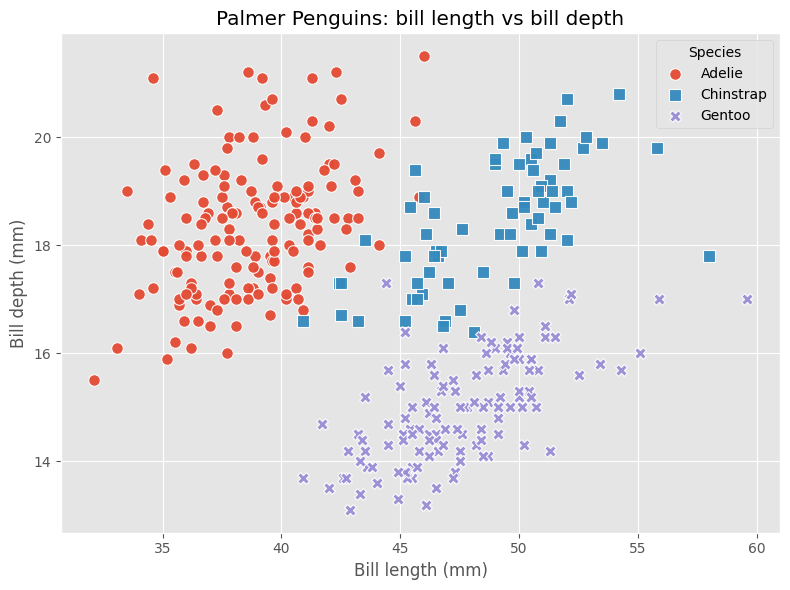

In [3]:
# Plot the labelled data for context only
fig, ax = plt.subplots(figsize=(8, 6))

markers = {"Adelie": "o", "Gentoo": "X", "Chinstrap": "s"}
for label in sorted(species.unique()):
    mask = species == label
    ax.scatter(
        penguins.loc[mask, "bill_length_mm"],
        penguins.loc[mask, "bill_depth_mm"],
        s=70,
        marker=markers[label],
        edgecolor="white",
        linewidth=0.8,
        label=label,
        alpha=0.95,
    )

ax.set_title("Palmer Penguins: bill length vs bill depth")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.legend(title="Species", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_species_context.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Fit a 3-component GMM

A GMM assumes the data come from a mixture of Gaussian distributions.  
EM alternates between:
- estimating component responsibilities (**E-step**)
- updating weights, means, and covariances (**M-step**)


In [4]:
# Fit a 3-component GMM with full covariance
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=10
)
gmm.fit(X_scaled)

# Get soft and hard assignments
component_probs = gmm.predict_proba(X_scaled)
component_ids = gmm.predict(X_scaled)

print("Mixture weights:", np.round(gmm.weights_, 3))
print("Converged:", gmm.converged_)
print("Iterations:", gmm.n_iter_)

Mixture weights: [0.351 0.457 0.192]
Converged: True
Iterations: 14


## 4. Components and covariance ellipses

The ellipses represent the covariance structure of each Gaussian component.  
This is the key figure for showing that a GMM models **shape, spread, and overlap**.


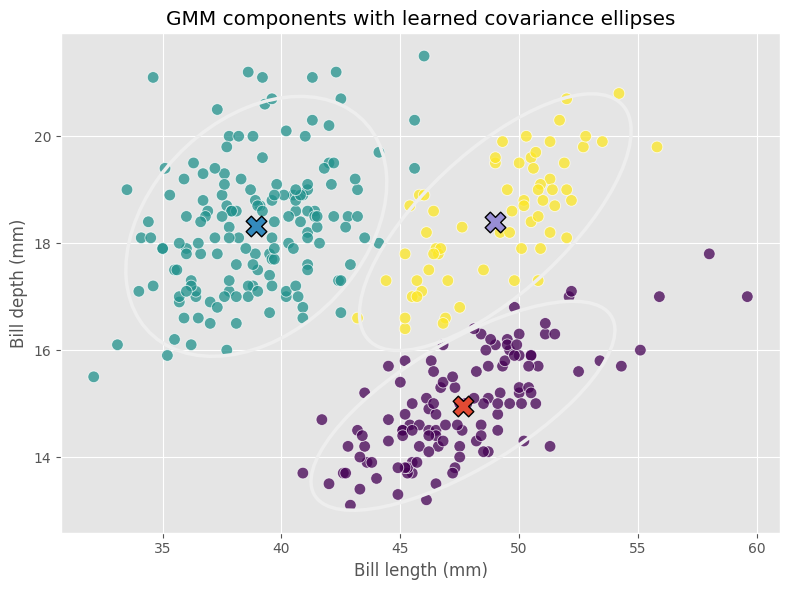

In [5]:
# Draw covariance ellipses in the original feature space
def plot_cov_ellipse(mean_scaled, cov_scaled, scaler, ax, n_std=2.0, **kwargs):
    # Convert mean and covariance back to original units
    scale = scaler.scale_
    mean = scaler.inverse_transform(mean_scaled.reshape(1, -1))[0]
    cov = cov_scaled * np.outer(scale, scale)

    # Get ellipse axes and angle
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ellipse)

# Plot GMM assignments and learned component shapes
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    penguins["bill_length_mm"],
    penguins["bill_depth_mm"],
    c=component_ids,
    s=70,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
)

means_original = scaler.inverse_transform(gmm.means_)
for k, (mean, cov) in enumerate(zip(gmm.means_, gmm.covariances_)):
    plot_cov_ellipse(mean, cov, scaler, ax, n_std=2.0, linewidth=2.5)
    ax.scatter(
        means_original[k, 0], means_original[k, 1],
        marker="X", s=220, edgecolor="black", linewidth=1.0
    )

ax.set_title("GMM components with learned covariance ellipses")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_gmm_ellipses.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Soft clustering: ambiguous penguins

A useful GMM output is the **posterior probability** of each point belonging to each component.

Below, I select the 10 most ambiguous penguins, meaning their largest component probability is relatively low.


In [6]:
# Find the penguins the model is least certain about
max_prob = component_probs.max(axis=1)
ambiguous_idx = np.argsort(max_prob)[:10]

# Build a small table for those cases
ambiguous = penguins.loc[ambiguous_idx, ["species", "bill_length_mm", "bill_depth_mm"]].copy()
ambiguous["component_0"] = component_probs[ambiguous_idx, 0]
ambiguous["component_1"] = component_probs[ambiguous_idx, 1]
ambiguous["component_2"] = component_probs[ambiguous_idx, 2]
ambiguous["max_prob"] = max_prob[ambiguous_idx]

ambiguous.round(3)

,species,bill_length_mm,bill_depth_mm,component_0,component_1,component_2,max_prob
277,Chinstrap,45.4,18.7,0.000,0.461,0.539,0.539
267,Gentoo,44.5,15.7,0.612,0.012,0.376,0.612
72,Adelie,45.8,18.9,0.000,0.387,0.613,0.613
296,Chinstrap,43.2,16.6,0.002,0.344,0.654,0.654
306,Chinstrap,42.5,16.7,0.000,0.654,0.346,0.654
128,Adelie,44.1,18.0,0.000,0.660,0.340,0.660
236,Gentoo,50.8,17.3,0.339,0.000,0.661,0.661
200,Gentoo,45.2,15.8,0.666,0.005,0.328,0.666
216,Gentoo,49.8,16.8,0.699,0.000,0.301,0.699
282,Chinstrap,46.0,18.9,0.000,0.299,0.701,0.701


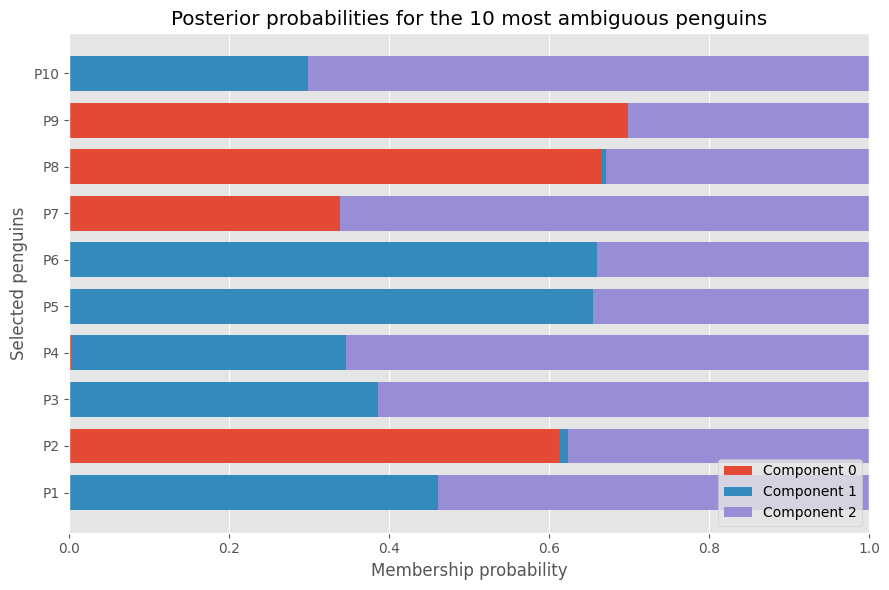

In [7]:
# Show soft membership for the most ambiguous penguins
fig, ax = plt.subplots(figsize=(9, 6))

labels = [f"P{i+1}" for i in range(len(ambiguous_idx))]
left = np.zeros(len(ambiguous_idx))

for k in range(gmm.n_components):
    vals = component_probs[ambiguous_idx, k]
    ax.barh(labels, vals, left=left, height=0.75, label=f"Component {k}")
    left += vals

ax.set_title("Posterior probabilities for the 10 most ambiguous penguins")
ax.set_xlabel("Membership probability")
ax.set_ylabel("Selected penguins")
ax.set_xlim(0, 1)
ax.legend(frameon=True, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_posterior_bars.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. How confident is the model overall?

This histogram shows how certain the model is about the **most likely** component for each penguin.
Values near 1 mean a confident assignment. Lower values indicate overlap or ambiguity.


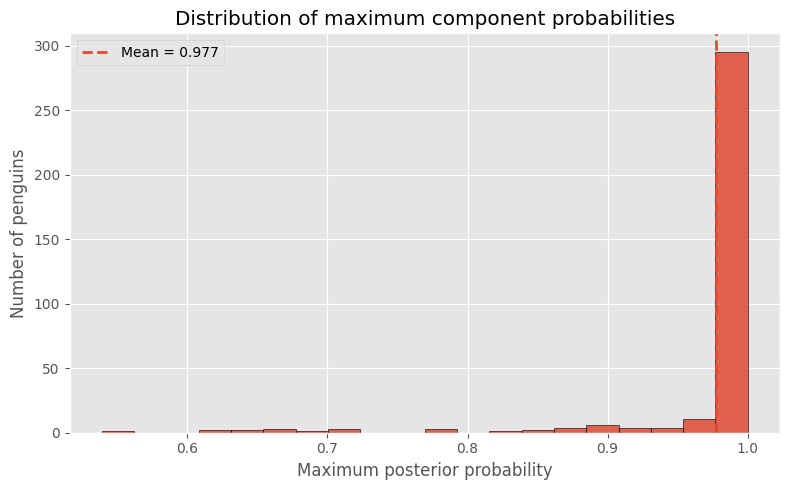

In [8]:
# Summarise model confidence across all observations
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(max_prob, bins=20, edgecolor="black", alpha=0.85)
ax.axvline(max_prob.mean(), linestyle="--", linewidth=2, label=f"Mean = {max_prob.mean():.3f}")
ax.set_title("Distribution of maximum component probabilities")
ax.set_xlabel("Maximum posterior probability")
ax.set_ylabel("Number of penguins")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_probability_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Model selection with BIC

A GMM needs a choice for:
- number of components
- covariance type

I use the **Bayesian Information Criterion (BIC)** to compare several settings.  
Lower BIC is better.


In [9]:
# Compare several GMM settings with BIC
cov_types = ["full", "tied", "diag", "spherical"]
n_components_range = range(1, 7)

bic_rows = []
for cov_type in cov_types:
    for n in n_components_range:
        model = GaussianMixture(
            n_components=n,
            covariance_type=cov_type,
            random_state=42,
            n_init=10
        )
        model.fit(X_scaled)
        bic_rows.append(
            {
                "covariance_type": cov_type,
                "n_components": n,
                "bic": model.bic(X_scaled),
            }
        )

bic_df = pd.DataFrame(bic_rows)
best_row = bic_df.loc[bic_df["bic"].idxmin()]
best_row

,9
covariance_type,tied
n_components,4
bic,1731.869484


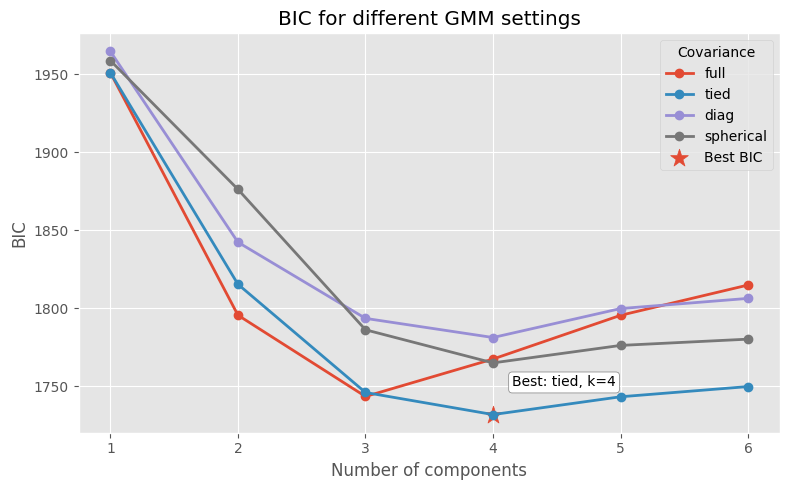

In [10]:
# Plot BIC values for each candidate model
fig, ax = plt.subplots(figsize=(8, 5))

for cov_type in cov_types:
    subset = bic_df[bic_df["covariance_type"] == cov_type]
    ax.plot(
        subset["n_components"],
        subset["bic"],
        marker="o",
        linewidth=2,
        label=cov_type,
    )

ax.scatter(best_row["n_components"], best_row["bic"], s=180, marker="*", label="Best BIC")
ax.annotate(
    f"Best: {best_row['covariance_type']}, k={int(best_row['n_components'])}",
    xy=(best_row["n_components"], best_row["bic"]),
    xytext=(best_row["n_components"] + 0.15, best_row["bic"] + 18),
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray"),
)

ax.set_title("BIC for different GMM settings")
ax.set_xlabel("Number of components")
ax.set_ylabel("BIC")
ax.legend(title="Covariance", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_bic.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. External check: component composition by species

This heatmap is **not** used for fitting.  
It is only an external check to see how the learned components align with the known penguin species.


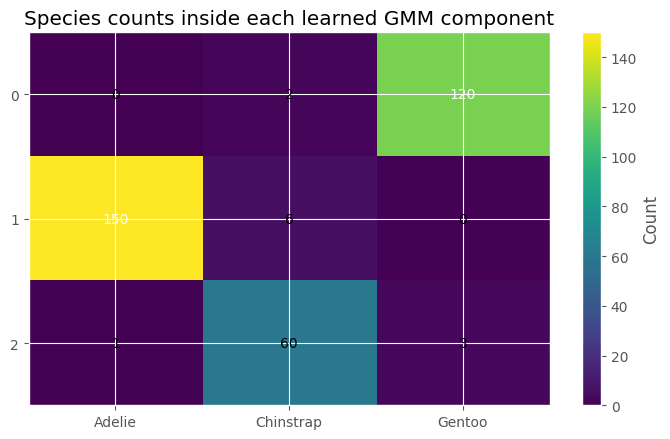

Species,Adelie,Chinstrap,Gentoo
Component,,,
0,0,2,120
1,150,6,0
2,1,60,3


In [11]:
# Compare learned components with species labels after fitting
ct = pd.crosstab(
    pd.Series(component_ids, name="Component"),
    pd.Series(species, name="Species")
)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(ct.values, aspect="auto")

ax.set_title("Species counts inside each learned GMM component")
ax.set_xticks(np.arange(ct.shape[1]))
ax.set_xticklabels(ct.columns)
ax.set_yticks(np.arange(ct.shape[0]))
ax.set_yticklabels(ct.index)

# Write counts inside each heatmap cell
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(
            j, i, ct.values[i, j],
            ha="center", va="center",
            color="white" if ct.values[i, j] > ct.values.max()/2 else "black"
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Count")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_component_species_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

ct

## 9. Short numerical summary

- mixture weights
- uncertainty summary
- optional external score against species labels


In [12]:
# Collect a few summary metrics for the tutorial text
summary = pd.DataFrame(
    {
        "metric": [
            "mean_max_posterior",
            "min_max_posterior",
            "median_max_posterior",
            "ARI_vs_species",
        ],
        "value": [
            max_prob.mean(),
            max_prob.min(),
            np.median(max_prob),
            adjusted_rand_score(pd.factorize(species)[0], component_ids),
        ],
    }
)

summary.round(3)

,metric,value
0,mean_max_posterior,0.977
1,min_max_posterior,0.539
2,median_max_posterior,1.000
3,ARI_vs_species,0.912


## GitHub Repository

- https://github.com/mi24acr/Machine_Learning_Tutorial_Hasan.git

